In [1]:
# 导入库
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import font_manager
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error
from sklearn.datasets import load_diabetes
from sklearn.model_selection import learning_curve
from sklearn.pipeline import make_pipeline
import warnings
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.datasets import fetch_california_housing 


# 全局字体设置：自动选择系统中可用的中文字体，避免中文标题显示为方块
candidate_fonts = ['Microsoft YaHei', 'SimHei', 'Noto Sans CJK SC', 'Source Han Sans CN', 'Arial Unicode MS']
available_fonts = {f.name for f in font_manager.fontManager.ttflist}
selected_font = next((f for f in candidate_fonts if f in available_fonts), None)
if selected_font:
    plt.rcParams['font.sans-serif'] = [selected_font]
plt.rcParams['axes.unicode_minus'] = False

数据理解

In [ ]:
# 1) 加载与概览

# 1. 加载数据（这里以经典的鸢尾花数据集为例，你也可以加载自己的CSV文件）

# 从网络加载
# url = "https://raw.githubusercontent.com/uiuc-cse/data-fa14/gh-pages/data/iris.csv"
# df = pd.read_csv(url)

# 从本地文件加载
df = pd.read_csv(r'E:\DeepLearning\Data\Iris Dataset.csv')

# 2. 查看数据的前几行 - 第一印象
print("数据的前5行：")
display(df.head())  
print("\n" + "="*50 + "\n")

# 3. 查看数据的整体信息：行数、列数、数据类型、内存占用
print("数据集的基本信息：")
df.info()
print("\n" + "="*50 + "\n")

# 4. 查看数据的形状（多少行，多少列）
print(f"数据集形状：{df.shape}") # 输出 (行数， 列数)
print(f"共有 {df.shape[0]} 条样本， {df.shape[1]} 个特征。")




数据的前5行：


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa




数据集的基本信息：
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


数据集形状：(150, 5)
共有 150 条样本， 5 个特征。


In [ ]:
# 2) 质量检查——发现缺失与异常

# 1. 检查缺失值
print("各特征缺失值数量：")
display(df.isnull().sum())
print("\n" + "="*50 + "\n")

# 若缺失值很多，可以计算缺失比例
missing_ratio = df.isnull().sum() / len(df) * 100
print("各特征缺失值比例（%）:")
display(missing_ratio.round(2))
print("\n" + "="*50 + "\n")

# 2. 检查数值型特征的统计摘要 - 可以发现异常值的线索
print("数值型特征的统计描述：")
display(df.describe())

各特征缺失值数量：
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64


各特征缺失值比例（%）:
sepal_length    0.0
sepal_width     0.0
petal_length    0.0
petal_width     0.0
species         0.0
dtype: float64


数值型特征的统计描述：
       sepal_length  sepal_width  petal_length  petal_width
count    150.000000   150.000000    150.000000   150.000000
mean       5.843333     3.054000      3.758667     1.198667
std        0.828066     0.433594      1.764420     0.763161
min        4.300000     2.000000      1.000000     0.100000
25%        5.100000     2.800000      1.600000     0.300000
50%        5.800000     3.000000      4.350000     1.300000
75%        6.400000     3.300000      5.100000     1.800000
max        7.900000     4.400000      6.900000     2.500000


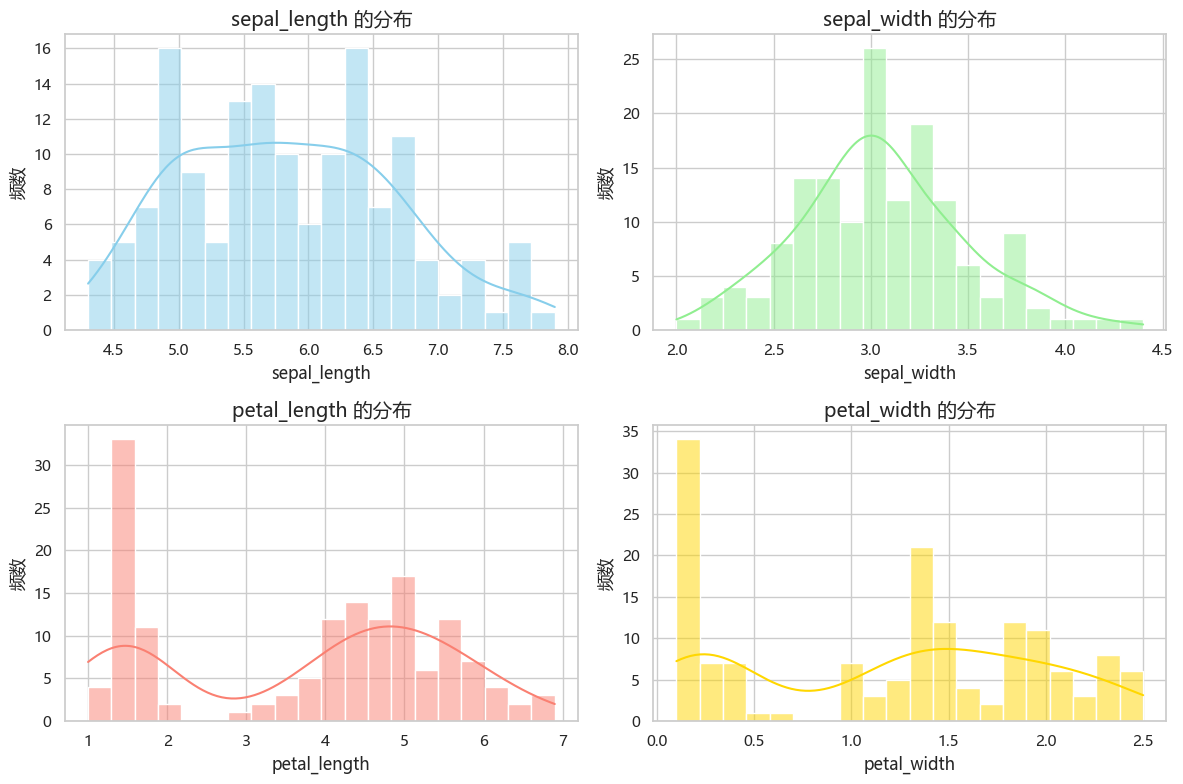

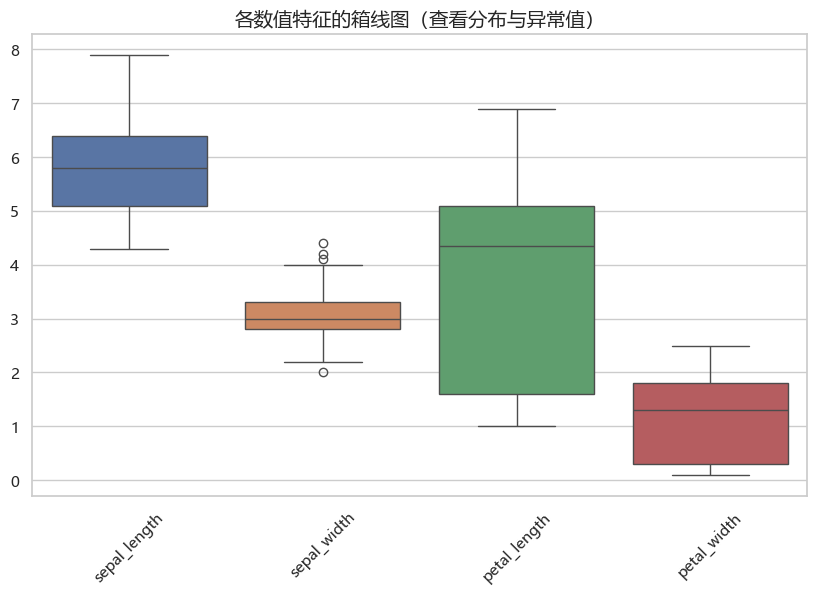


绘制特征间关系的散点图矩阵...（这能帮助我们发现特征之间的关联）


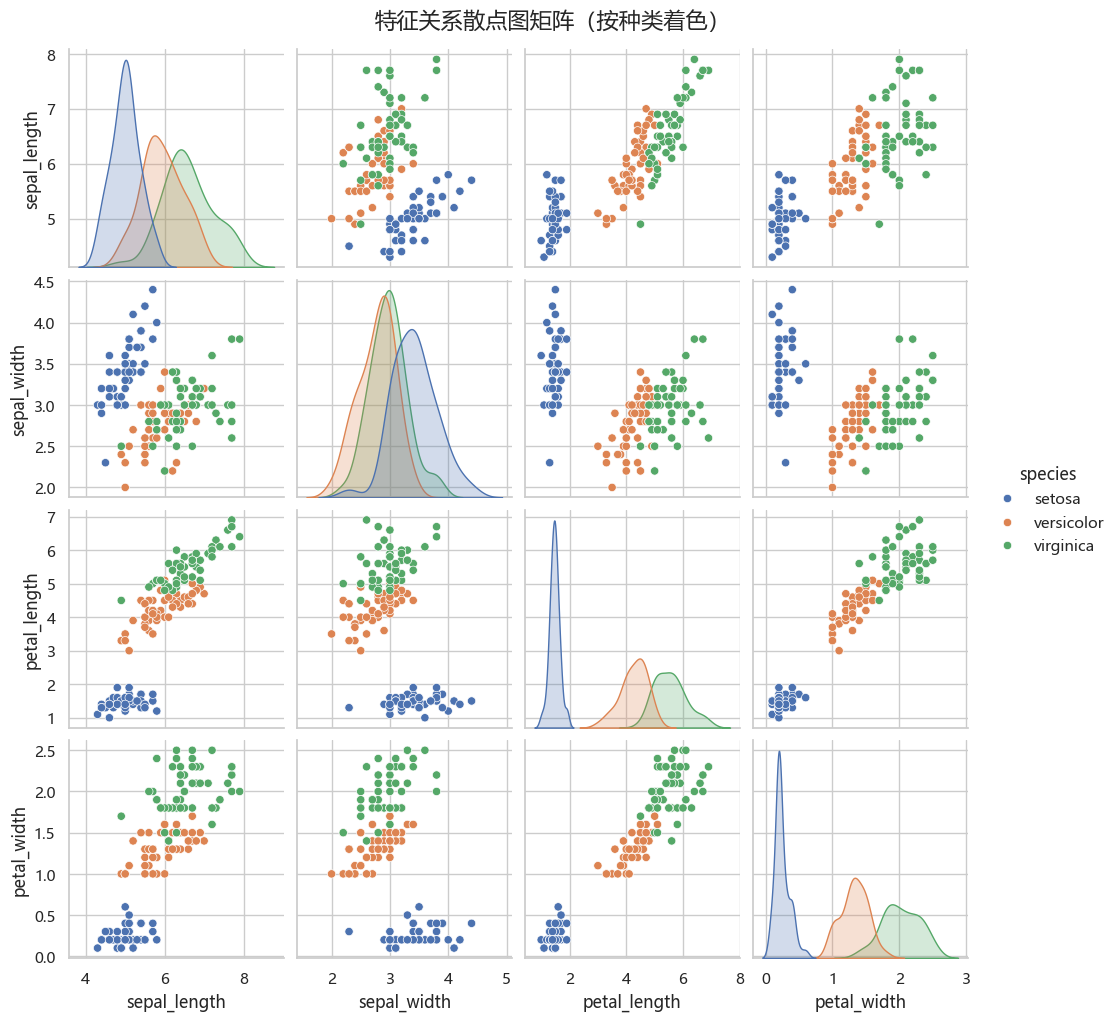

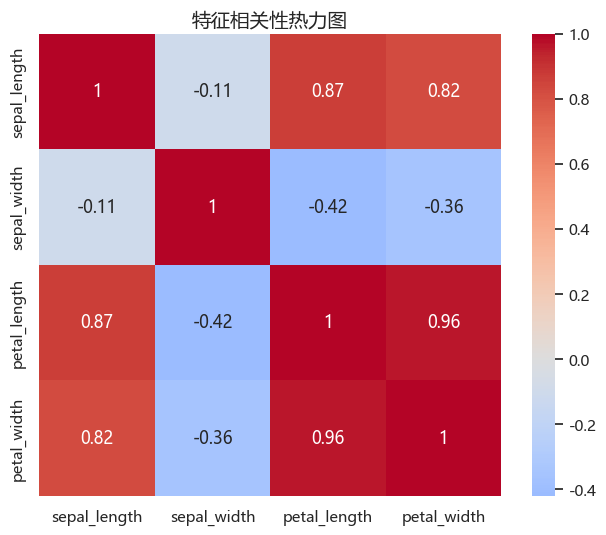

In [ ]:
# 3) 分布与关系可视化

# 设置图表风格
if 'selected_font' in globals() and selected_font:
    sns.set_theme(
        style="whitegrid",
        rc={"font.sans-serif": [selected_font], "axes.unicode_minus": False}
    )
else:
    sns.set_theme(style="whitegrid")
    plt.rcParams['axes.unicode_minus'] = False

# 1. 单变量分布 - 了解每个特征自身的分布情况
fig, axes = plt.subplots(2, 2, figsize=(12, 8))  # 创建2x2的画布
features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
colors = ['skyblue', 'lightgreen', 'salmon', 'gold']

for i, (ax, feature, color) in enumerate(zip(axes.flat, features, colors)):
    # 绘制直方图（分布）与核密度估计曲线
    sns.histplot(df[feature], kde=True, ax=ax, color=color, bins=20)
    ax.set_title(f'{feature} 的分布', fontsize=14)
    ax.set_xlabel(feature)
    ax.set_ylabel('频数')

plt.tight_layout()
plt.show()

# 2. 箱线图 - 查看数据分布与异常值（更直观）
plt.figure(figsize=(10, 6))
# 选择数值列绘制箱线图
df_box = df.drop(columns=['species'])  # 假设'species'是文本标签列，先去掉
sns.boxplot(data=df_box)
plt.title('各数值特征的箱线图（查看分布与异常值）', fontsize=14)
plt.xticks(rotation=45)
plt.show()

# 3. 变量间关系 - 散点图矩阵
print("\n绘制特征间关系的散点图矩阵...（这能帮助我们发现特征之间的关联）")
# 使用Seaborn的pairplot，hue参数可以根据类别着色（如鸢尾花的品种）
sns.pairplot(df, hue='species', height=2.5)
plt.suptitle('特征关系散点图矩阵（按种类着色）', y=1.02, fontsize=16)
plt.show()

# 4. 相关性热力图 - 量化特征间的线性关系
plt.figure(figsize=(8, 6))
# 计算数值特征之间的相关系数
numeric_df = df.select_dtypes(include=['float64', 'int64'])
correlation_matrix = numeric_df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, square=True)
plt.title('特征相关性热力图', fontsize=14)
plt.show()

数据清洗  

数据清洗不是一个一次性的步骤，而是一个迭代的过程。以下是一些最佳实践：  
1. 先探索，后清洗：在动手清洗之前，务必使用 df.describe()、df.info()、可视化（如直方图、箱线图）等手段充分了解你的数据。  
2. 备份原始数据：永远保留一份原始的、未经修改的数据副本。所有清洗操作都应在副本上进行。  
3. 记录清洗步骤：将你的清洗逻辑（如为什么用中位数填充、异常值的边界如何确定）记录下来。这对于项目可复现性和团队协作至关重要。  
4. 结合业务逻辑：数据清洗不是纯数学操作。例如，"年龄=0"在人口统计数据中是错误，但在婴幼儿产品数据中可能是合理的。始终与领域专家保持沟通。  
5. 迭代进行：清洗后，进入建模阶段。如果模型效果不佳，应回头检查数据质量，可能需要调整清洗策略。  

In [ ]:
# 1) 数据加载

df = pd.read_csv('E:\DeepLearning\Data\Iris Dataset.csv') # 文件路径

# 查看数据的基本信息和前几行
print("数据集形状（行，列）:", df.shape)
print("\n数据前5行：")
display(df.head())
print("\n数据基本信息：")
df.info()
print("\n数据统计描述：")
display(df.describe())

数据集形状（行，列）: (150, 5)

数据前5行：


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa



数据基本信息：
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB

数据统计描述：


,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [ ]:
# 2) 处理缺失值

# 1. 检查缺失值
print("各列缺失值数量：")
print(df.isnull().sum())

# 2. 处理缺失值 - 方法一：删除
# 删除任何包含缺失值的行（适用于缺失值很少的情况）
df_dropped = df.dropna()
print(f"\n删除缺失值后，数据形状: {df_dropped.shape}")

# 3. 处理缺失值 - 方法二：填充
# 更常用的方法是根据列的特性进行填充
df_filled = df.copy()

# 对于数值型列（如'年龄'），用中位数填充（比均值更抗异常值影响）
if '年龄' in df_filled.columns:
    df_filled['年龄'] = df_filled['年龄'].fillna(df_filled['年龄'].median())

# 对于分类列（如'城市'），用众数（最频繁出现的值）填充
if '城市' in df_filled.columns:
    df_filled['城市'] = df_filled['城市'].fillna(df_filled['城市'].mode()[0])

# 对于可能随时间变化的列（如'上次消费金额'），有时用0填充更有业务意义
if '上次消费金额' in df_filled.columns:
    df_filled['上次消费金额'] = df_filled['上次消费金额'].fillna(0)

print("\n填充缺失值后，各列缺失值数量：")
print(df_filled.isnull().sum())

各列缺失值数量：
年龄    2
工资    1
城市    1
dtype: int64

删除缺失值后，数据形状: (1, 3)

填充缺失值后，各列缺失值数量：
年龄    0
工资    1
城市    0
dtype: int64


In [ ]:
# 3) 识别与处理异常值

# 我们以'年收入'为例，假设它应该是一个合理的正值
if '年收入' in df_filled.columns:
    # 方法一：使用四分位距（IQR）法识别
    Q1 = df_filled['年收入'].quantile(0.25)
    Q3 = df_filled['年收入'].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # 找出异常值
    outliers = df_filled[(df_filled['年收入'] < lower_bound) | (df_filled['年收入'] > upper_bound)]
    print(f"\n使用IQR法发现的'年收入'异常值数量: {len(outliers)}")

    # 处理异常值：这里选择用上下边界值进行截断（Winsorization）
    df_filled['年收入'] = np.where(df_filled['年收入'] > upper_bound, upper_bound,
                                   np.where(df_filled['年收入'] < lower_bound, lower_bound, df_filled['年收入']))

    print("已对'年收入'的异常值进行截断处理。")

In [ ]:
# 4) 处理不一致性

# 创建一个新的DataFrame来存储清洗后的数据，避免修改原始数据
df_cleaned = df_filled.copy()

# 1. 标准化文本格式：例如，将'城市'列统一为首字母大写
if '城市' in df_cleaned.columns:
    df_cleaned['城市'] = df_cleaned['城市'].str.title()

# 2. 映射统一值：例如，将性别信息统一为'男'和'女'
if '性别' in df_cleaned.columns:
    gender_mapping = {'male': '男', 'female': '女', 'M': '男', 'F': '女'}
    df_cleaned['性别'] = df_cleaned['性别'].replace(gender_mapping)
    # 也可以使用 .map() 函数，但 .replace() 更灵活，未指定的值保持不变

# 3. 转换数据类型：确保数值列是数字类型
if '年龄' in df_cleaned.columns:
    df_cleaned['年龄'] = pd.to_numeric(df_cleaned['年龄'], errors='coerce') # errors='coerce'将错误转换为NaN
    # 转换后，可以再次用中位数填充因转换产生的新NaN
    df_cleaned['年龄'] = df_cleaned['年龄'].fillna(df_cleaned['年龄'].median())

print("\n数据清洗完成！查看清洗后的数据前5行：")
display(df_cleaned.head())


数据清洗完成！查看清洗后的数据前5行：


,年龄,工资,城市
0,25.0,50000.0,北京
1,30.0,54000.0,上海
2,30.0,NaN,广州
3,35.0,62000.0,北京
4,30.0,58000.0,北京


In [ ]:
# 5) 处理重复值

# 检查并删除完全重复的行
duplicate_rows = df_filled.duplicated()
print(f"\n发现完全重复的行数: {duplicate_rows.sum()}")

# 删除这些重复行，只保留第一次出现的记录
df_cleaned = df_filled.drop_duplicates()
print(f"删除重复值后，数据形状: {df_cleaned.shape}")


发现完全重复的行数: 3
删除重复值后，数据形状: (147, 5)


特征工程

In [ ]:
# 1) 特征处理——最基础的一步，目的是将原始数据"清洗"成干净、规整的格式。

# a) 处理缺失值
# 创建一个包含缺失值的示例 DataFrame
data = {'年龄': [25, np.nan, 30, 35, np.nan],
        '工资': [50000, 54000, np.nan, 62000, 58000],
        '城市': ['北京', '上海', '广州', np.nan, '北京']}
df = pd.DataFrame(data)
print("原始数据：")
display(df)

# 1. 删除缺失值（删除任何包含 NaN 的行）
df_dropped = df.dropna()
print("\n删除缺失值后：")
display(df_dropped)

# 2. 填充缺失值
# 数值列用均值填充
df_filled = df.copy()
df_filled['年龄'] = df_filled['年龄'].fillna(df_filled['年龄'].mean())
df_filled['工资'] = df_filled['工资'].fillna(df_filled['工资'].mean())
# 类别列用众数填充
df_filled['城市'] = df_filled['城市'].fillna(df_filled['城市'].mode()[0])
print("\n填充缺失值后：")
display(df_filled)


原始数据：


,年龄,工资,城市
0,25.0,50000.0,北京
1,NaN,54000.0,上海
2,30.0,NaN,广州
3,35.0,62000.0,NaN
4,NaN,58000.0,北京



删除缺失值后：


,年龄,工资,城市
0,25.0,50000.0,北京



填充缺失值后：


,年龄,工资,城市
0,25.0,50000.0,北京
1,30.0,54000.0,上海
2,30.0,56000.0,广州
3,35.0,62000.0,北京
4,30.0,58000.0,北京


In [ ]:
# b) 处理异常值
"""
异常值是与大部分数据明显不同的值，可能会干扰模型。
常用检测方法有：

标准差法：认为超出均值 ± 3倍标准差范围的值是异常值。
箱线图法：认为小于 Q1 - 1.5*IQR 或大于 Q3 + 1.5*IQR 的值是异常值（IQR = Q3 - Q1）。
处理方式可以是删除、替换为边界值或视为缺失值处理。
"""

In [32]:
# c) 数据标准化/归一化
"""
许多模型(如 SVM、KNN、神经网络)对特征的尺度敏感。我们需要将不同尺度的特征转换到同一尺度。

方法	公式	                                说明	                   适用场景
标准化	(x - 均值) / 标准差	        处理后数据均值为0，标准差为1	   数据分布近似正态分布时
归一化	(x - min) / (max - min)	    将数据缩放到 [0, 1] 区间	    数据边界明确，需要快速计算时
"""

# 示例数据
data = np.array([[1000, 25],
                 [1500, 30],
                 [800, 20],
                 [1200, 28]])

# 标准化
scaler_standard = StandardScaler()
data_standardized = scaler_standard.fit_transform(data)
print("标准化后的数据（均值~0， 标准差~1）：")
print(data_standardized)
print(f"均值： {data_standardized.mean(axis=0)}")
print(f"标准差： {data_standardized.std(axis=0)}")

# 归一化
scaler_minmax = MinMaxScaler()
data_normalized = scaler_minmax.fit_transform(data)
print("\n归一化后的数据（范围[0,1]）：")
print(data_normalized)

标准化后的数据（均值~0， 标准差~1）：
[[-0.48336824 -0.19911699]
 [ 1.45010473  1.12832963]
 [-1.25675744 -1.52656362]
 [ 0.29002095  0.59735098]]
均值： [-2.77555756e-17  2.77555756e-17]
标准差： [1. 1.]

归一化后的数据（范围[0,1]）：
[[0.28571429 0.5       ]
 [1.         1.        ]
 [0.         0.        ]
 [0.57142857 0.8       ]]


In [ ]:
# 2) 特征构造——通过组合或转换现有特征，创造出新的、更具预测力的特征。

# a) 对数值特征进行变换
"""
多项式特征：创建特征的平方、立方等，帮助线性模型学习非线性关系。
分箱：将连续年龄分为"青年"、"中年"、"老年"等区间，将连续数据离散化。
数学变换：使用对数、指数等变换改变数据分布。
"""

# b) 对类别特征进行编码
"""
机器学习模型无法直接处理"北京"、"上海"这样的文本。需要将其转换为数字。

方法	                说明	                                  特点
标签编码    为每个类别分配一个唯一整数，如北京:0，上海:1	简单，但可能引入错误的顺序关系（模型可能认为 1>0）
独热编码    为每个类别创建一个新的二进制特征（0或1）	    能消除顺序误解，但若类别很多，会导致特征维度爆炸
"""

# 示例数据
df_cat = pd.DataFrame({'城市': ['北京', '上海', '广州', '北京', '深圳']})

# 标签编码
le = LabelEncoder()
df_cat['城市_标签编码'] = le.fit_transform(df_cat['城市'])
print("标签编码结果：")
print(df_cat)

# 独热编码
# 方法1: 使用 pandas 的 get_dummies
df_onehot_pd = pd.get_dummies(df_cat['城市'], prefix='城市')
print("\n使用 pandas 进行独热编码：")
print(df_onehot_pd)

# 方法2: 使用 sklearn 的 OneHotEncoder (更常用于管道)
ohe = OneHotEncoder(sparse_output=False) # sparse_output=False 返回数组而非稀疏矩阵
encoded_array = ohe.fit_transform(df_cat[['城市']]) # 注意输入是二维的
print("\n使用 sklearn 进行独热编码（数组形式）：")
print(encoded_array)
print("新特征名称：", ohe.get_feature_names_out())

特征重要性排序：
                      特征       重要性
23            worst area  0.139357
27  worst concave points  0.132225
7    mean concave points  0.107046
20          worst radius  0.082848
22       worst perimeter  0.080850
2         mean perimeter  0.067990
6         mean concavity  0.066917
3              mean area  0.060462
26       worst concavity  0.037339
0            mean radius  0.034843


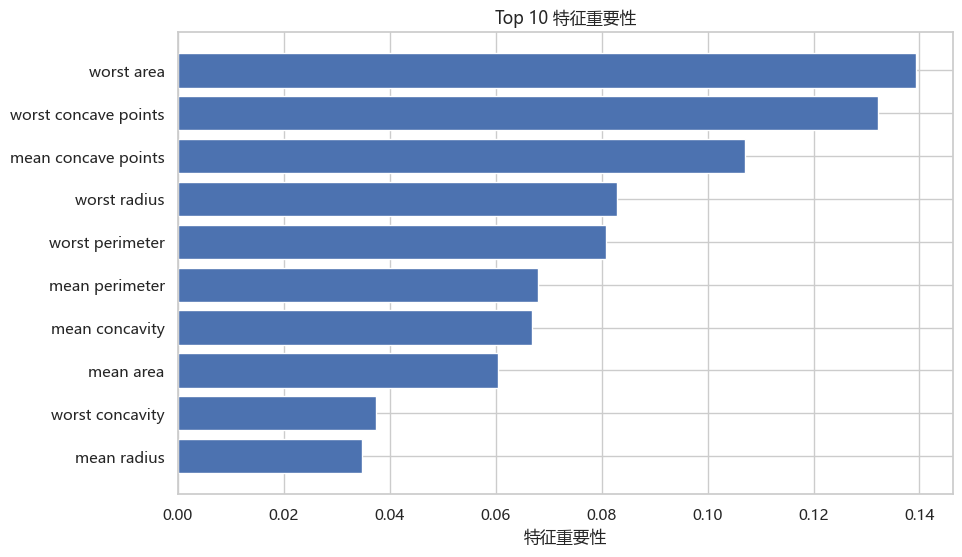


筛选出的特征： ['worst area', 'worst concave points', 'mean concave points', 'worst radius', 'worst perimeter', 'mean perimeter', 'mean concavity', 'mean area', 'worst concavity', 'mean radius']


In [35]:
# 3) 特征选择——从所有特征中挑选出最重要的一个子集，以降低维度、减少过拟合风险。
"""
方法	 说明
过滤法	 根据特征与目标变量的统计相关性（如方差、卡方检验、互信息）进行排序筛选。独立于任何模型。
包裹法	 将特征选择看作一个搜索问题，使用模型性能作为评价标准（如递归特征消除 RFE）。效果较好，但计算成本高。
嵌入法	 在模型训练过程中自动进行特征选择（如 L1 正则化 LASSO 回归、树模型的特征重要性）
"""

# 加载数据集
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

# 训练一个随机森林模型，它会计算特征重要性
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X, y)

# 获取特征重要性
importances = model.feature_importances_
feature_importance_df = pd.DataFrame({
    '特征': data.feature_names,
    '重要性': importances
}).sort_values('重要性', ascending=False)

print("特征重要性排序：")
print(feature_importance_df.head(10)) # 查看最重要的10个特征

# 可视化
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['特征'][:10], feature_importance_df['重要性'][:10])
plt.xlabel('特征重要性')
plt.title('Top 10 特征重要性')
plt.gca().invert_yaxis() # 让最重要的在顶部
plt.show()

# 假设我们选择重要性大于0.03的特征
selected_features = feature_importance_df[feature_importance_df['重要性'] > 0.03]['特征'].tolist()
print(f"\n筛选出的特征： {selected_features}")

数据可视化

In [5]:
# 设置图表风格，让图表更好看
sns.set_style("whitegrid")
# -------------------------- 设置中文字体 start --------------------------
plt.rcParams['font.sans-serif'] = [
    # Windows 优先
    'SimHei', 'Microsoft YaHei',
    # macOS 优先
    'PingFang SC', 'Heiti TC',
    # Linux 优先
    'WenQuanYi Micro Hei', 'DejaVu Sans'
]
# 修复负号显示为方块的问题
plt.rcParams['axes.unicode_minus'] = False
# -------------------------- 设置中文字体 end --------------------------


数据形状（行数，列数）: (891, 15)

数据前5行：


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True



数据基本信息（类型、非空值数量等）：
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


None

In [2]:
# 加载数据
# 这里我们直接从 seaborn 的内置数据集加载
df = sns.load_dataset('titanic')

# 查看数据的前几行和基本信息
print("数据形状（行数，列数）:", df.shape)
print("\n数据前5行：")
display(df.head())
print("\n数据基本信息（类型、非空值数量等）：")
display(df.info())

数据形状（行数，列数）: (891, 15)

数据前5行：


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True



数据基本信息（类型、非空值数量等）：
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


None

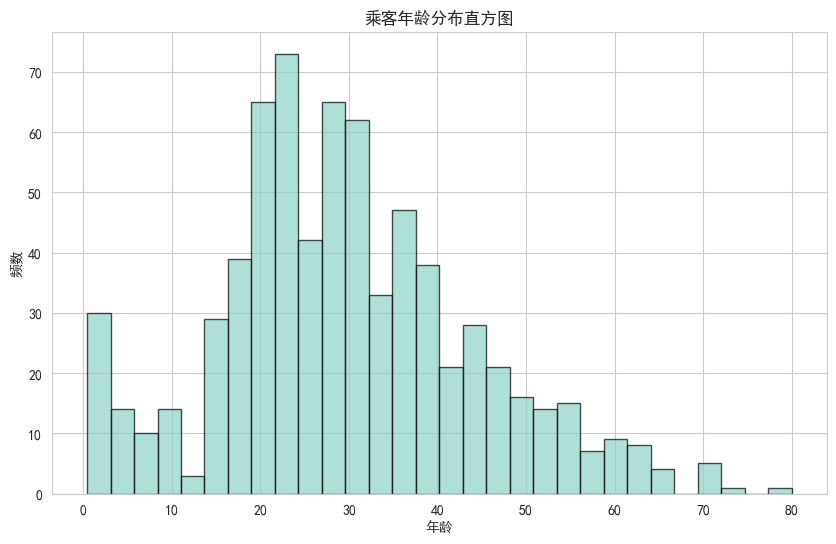

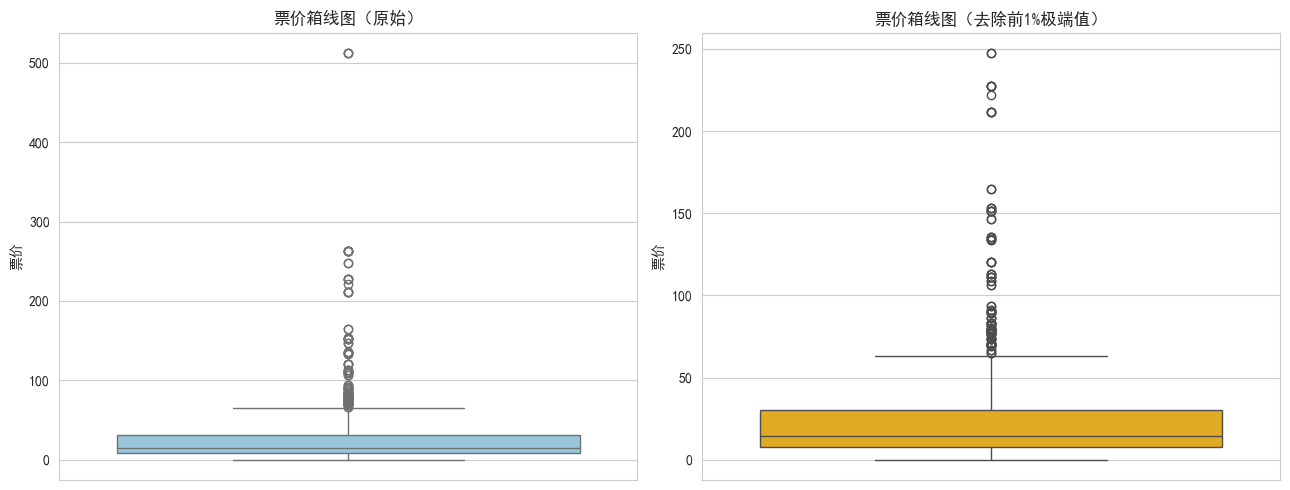

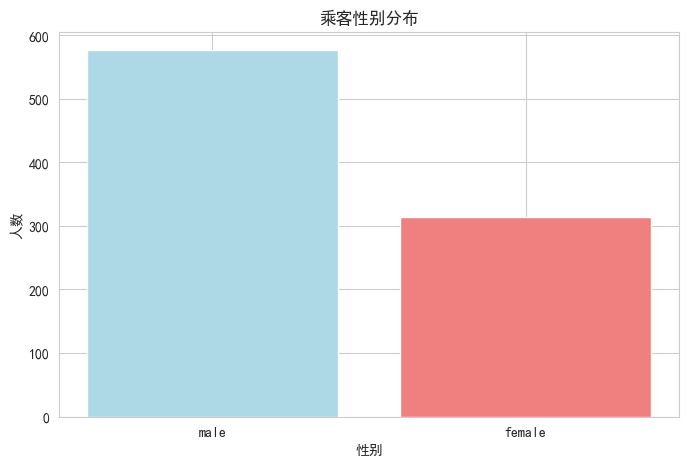

In [11]:
# 单变量分析：了解单个特征的分布

# 1. 数值型特征：直方图与箱线图
"""
对于像 age（年龄）、fare（票价）这样的连续数值型特征，我们常用直方图和箱线图。
直方图展示了数据在不同区间（"桶"）内的频率分布。
"""

# a) 绘制年龄的直方图
plt.figure(figsize=(10, 6))  # 设置图表大小
plt.hist(df['age'].dropna(), bins=30, edgecolor='black', alpha=0.7)  # dropna() 忽略缺失值
plt.title('乘客年龄分布直方图')
plt.xlabel('年龄')
plt.ylabel('频数')
plt.show()
# 解读：这张图可以告诉我们乘客的年龄主要集中在哪个区间（例如 20-30 岁），分布是否对称，是否有异常值等。

# b) 绘制票价箱线图（原始 + 去极值视图）
fare = df['fare'].dropna()
upper_99 = fare.quantile(0.99)
fare_zoom = fare[fare <= upper_99]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 原始箱线图：保留全部异常值
sns.boxplot(y=fare, ax=axes[0], color='#8ecae6')
axes[0].set_title('票价箱线图（原始）')
axes[0].set_ylabel('票价')

# 去极值视图：方便观察主体分布
sns.boxplot(y=fare_zoom, ax=axes[1], color='#ffb703')
axes[1].set_title('票价箱线图（去除前1%极端值）')
axes[1].set_ylabel('票价')

plt.tight_layout()
plt.show()
"""
解读：箱体中间的线是中位数。箱体上下边界是上四分位数（Q3）和下四分位数（Q1）。
上下"胡须"通常延伸到 1.5 倍四分位距以内的最远数据点，之外的点被视为
异常值（图中上方的圆圈）。这张图立刻告诉我们，票价存在很多极高的异常值。
"""

# 2. 类别型特征：柱状图
# 绘制乘客性别的柱状图
survival_counts = df['sex'].value_counts()
plt.figure(figsize=(8, 5))
plt.bar(survival_counts.index, survival_counts.values, color=['lightblue', 'lightcoral'])
plt.title('乘客性别分布')
plt.xlabel('性别')
plt.ylabel('人数')
plt.show()

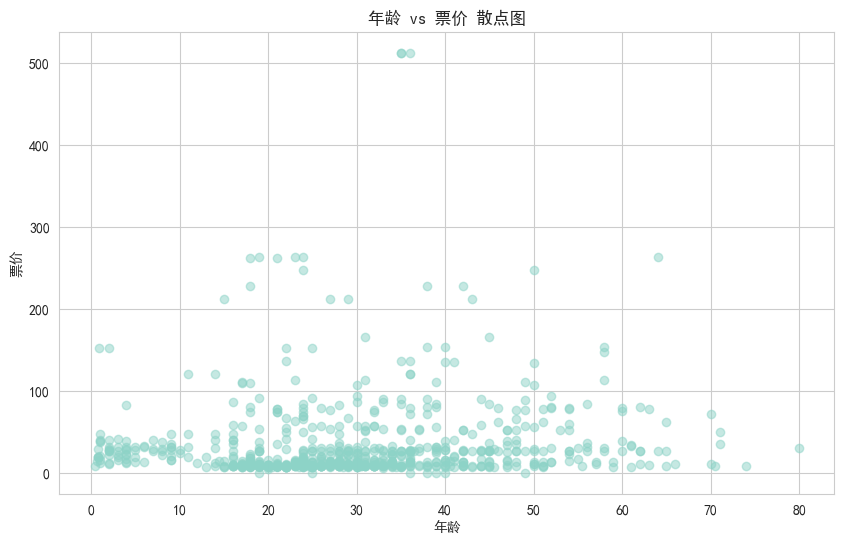

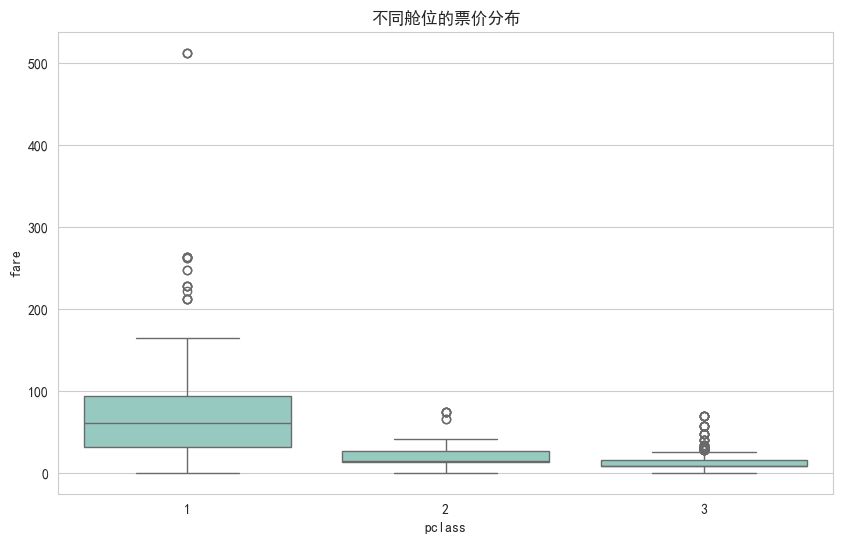

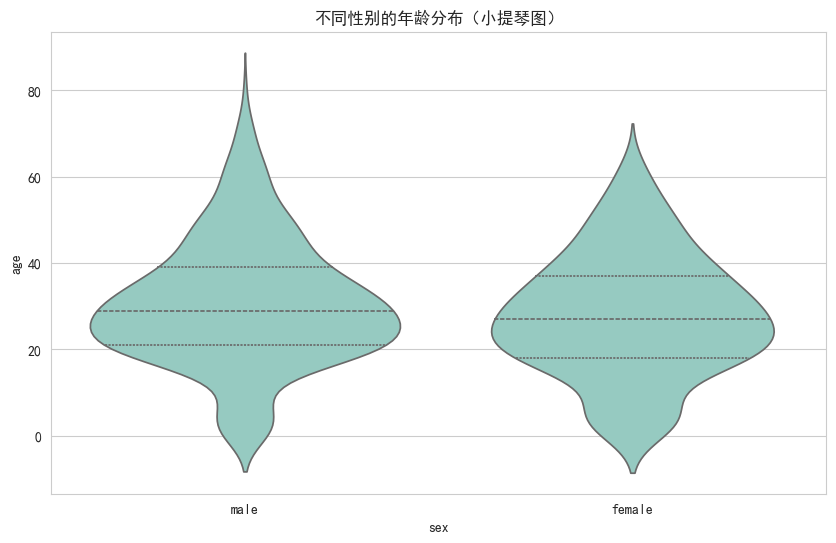

survived         0         1
sex                         
female    0.257962  0.742038
male      0.811092  0.188908


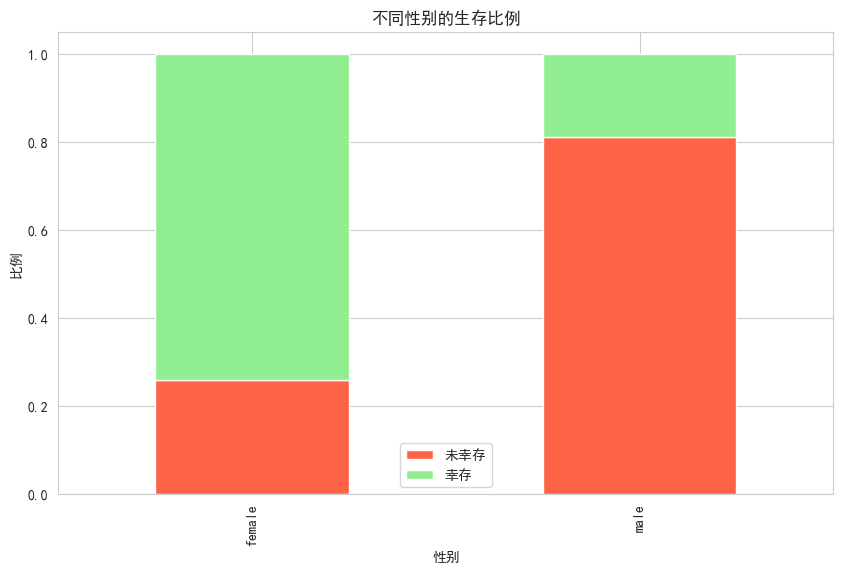

In [ ]:
# 双变量分析：探索特征间的关系

# 1. 数值 vs 数值：散点图
# 绘制年龄与票价的散点图
plt.figure(figsize=(10, 6))
plt.scatter(df['age'], df['fare'], alpha=0.5) # alpha 设置透明度，便于观察点密度
plt.title('年龄 vs 票价 散点图')
plt.xlabel('年龄')
plt.ylabel('票价')
plt.show()
"""
解读：点的分布模式可以暗示相关性。例如，如果点大致沿一条斜线分布，则说明两者相关。
从这张图看，年龄和票价没有明显的线性关系，但能再次确认高票价（异常值）的存在。
"""

# 2. 类别 vs 数值：分组箱线图或小提琴图
# a) 绘制分组箱线图 (pclass: 舱位等级，1/2/3等舱)
plt.figure(figsize=(10, 6))
sns.boxplot(x='pclass', y='fare', data=df)
plt.title('不同舱位的票价分布')
plt.show()
# 解读：非常清晰！舱位等级越高（1 等舱），票价的中位数和整体范围都显著更高。这完全符合我们的常识。

# b) 绘制不同性别下年龄分布的小提琴图
plt.figure(figsize=(10, 6))
sns.violinplot(x='sex', y='age', data=df, inner='quartile') # inner 参数显示四分位线
plt.title('不同性别的年龄分布（小提琴图）')
plt.show()

# 3. 类别 vs 类别：堆叠柱状图或热力图
# 创建性别与生存情况的交叉表
cross_tab = pd.crosstab(df['sex'], df['survived'], normalize='index') # normalize='index' 按行计算比例
print(cross_tab)

# 绘制堆叠柱状图
cross_tab.plot(kind='bar', stacked=True, figsize=(10, 6), color=['tomato', 'lightgreen'])
plt.title('不同性别的生存比例')
plt.xlabel('性别')
plt.ylabel('比例')
plt.legend(['未幸存', '幸存'])
plt.show()
"""
解读：从图表和交叉表可以明显看出，
女性的幸存比例远高于男性。这是一个非常强的信号，说明 sex 特征对于预测生存至关重要。
"""

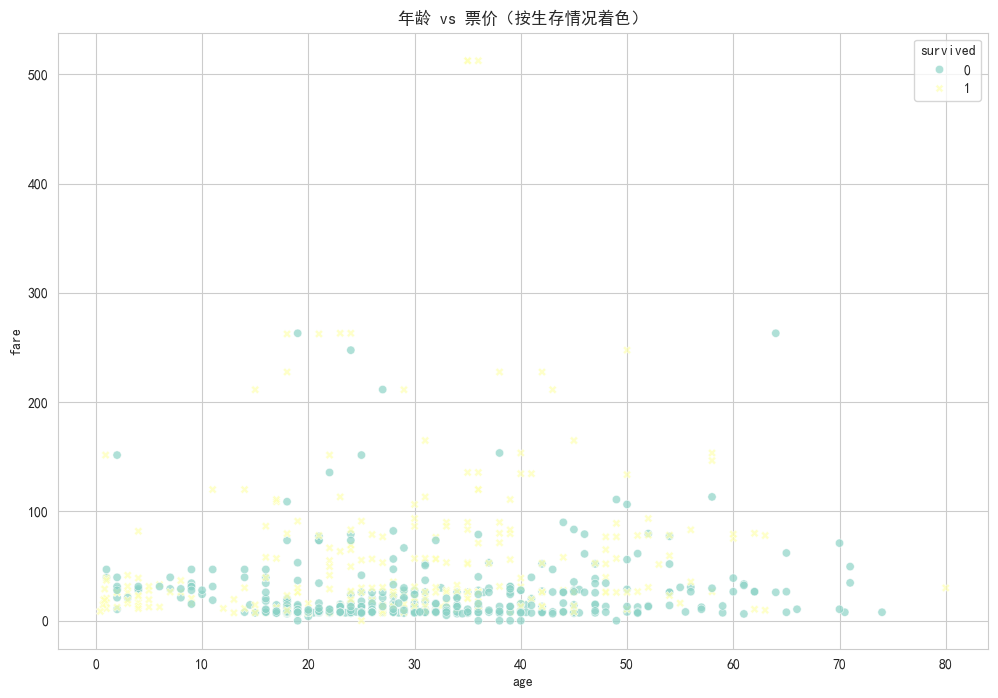

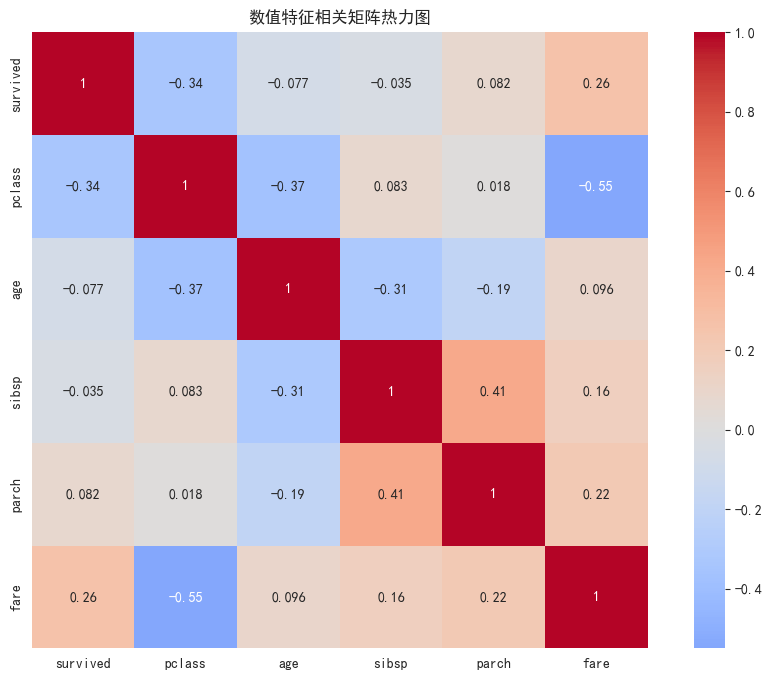

In [ ]:
# 多变量分析与高级可视化

# 1. 带分组的散点图
# 在年龄-票价散点图中，用颜色区分是否幸存
plt.figure(figsize=(12, 8))
sns.scatterplot(x='age', y='fare', hue='survived', style='survived', data=df, alpha=0.7)
plt.title('年龄 vs 票价（按生存情况着色）')
plt.show()
# 解读：这张图可以让我们直观地感受，幸存者（橙色）和非幸存者（蓝色）在"年龄-票价"这个二维空间中的分布是否有区别。

# 2. 相关矩阵热力图
# 选择数值型列
numeric_df = df.select_dtypes(include=['float64', 'int64'])

# 计算相关系数矩阵
corr_matrix = numeric_df.corr()

# 绘制热力图
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, square=True)
plt.title('数值特征相关矩阵热力图')
plt.show()
"""
解读：颜色越暖（红），表示正相关性越强；越冷（蓝），表示负相关性越强。
annot=True 将具体数值显示在方格内。例如，pclass（舱位）和 fare（票价）呈强负相关（-0.55），
即舱位号越小（等级越高），票价越高，这与我们之前的分析一致。
"""

训练集测试集划分

In [8]:
# 划分策略

# 1. 随机划分：将数据随机分为训练集和测试集，常用比例是 80% 训练，20% 测试。
X = df.drop(columns=['survived'])
y = df['survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"训练集样本数：{len(X_train)}")
print(f"测试集样本数：{len(X_test)}")
"""
代码解析：
train_test_split：这是 scikit-learn 中用于划分数据的核心函数。
X, y：输入的特征数据和对应的标签。
test_size=0.2：指定测试集的大小比例为 20%（即训练集占 80%）。你也可以用 train_size=0.8 来指定。
random_state=42：设置一个随机种子。
这能确保每次运行代码时，划分的结果都是完全相同的，这对于实验的可复现性至关重要。你可以将其设置为任意整数。
"""

# 2. 分层抽样划分:数据集的类别分布不均衡（例如，90%是A类，10%是B类）,分层抽样可以确保划分后的训练集和测试集中，各个类别的比例与原始数据集保持一致。
# 假设 y 是分类标签
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
# 检查划分后的类别比例
from collections import Counter
print("原始数据类别分布：", Counter(y))
print("训练集类别分布：", Counter(y_train))
print("测试集类别分布：", Counter(y_test))
# 代码解析：stratify=y：这是关键参数。它告诉函数按照标签 y 的类别分布来进行分层抽样。

# 时间序列数据划分
"""
对于时间序列数据（如股票价格、每日气温），数据点之间存在时间上的依赖关系。
我们不能随机打乱，因为未来的数据不能用来预测过去。
通常的做法是按时间顺序划分：用前 80% 时间的数据作为训练集，后 20% 的数据作为测试集。
"""
# 示例：时间序列数据的顺序划分
split_index = int(len(X) * 0.8) # 计算80%位置的索引

X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

print(f"训练集时间范围：前 {split_index} 个样本")
print(f"测试集时间范围：后 {len(X) - split_index} 个样本")


训练集样本数：712
测试集样本数：179
原始数据类别分布： Counter({0: 549, 1: 342})
训练集类别分布： Counter({0: 439, 1: 273})
测试集类别分布： Counter({0: 110, 1: 69})
训练集时间范围：前 712 个样本
测试集时间范围：后 179 个样本


In [12]:
# 验证集与交叉验证
"""
数据集划分：训练集、验证集、测试集
训练集：用于模型参数的学习。
验证集：用于在训练过程中调整超参数、选择模型或进行早停。它相当于"模拟考"。
测试集：在模型和超参数都确定后，用于最终、一次性的性能评估。它是"最终大考"。
"""

# 示例：先划分出训练+验证集 与 测试集，再从训练+验证集中划分出验证集
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=42) # 先分出15%作为最终测试集
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.176, random_state=42) # 从剩下的85%中分出约15%作为验证集

# 计算比例： 0.85 * 0.176 ≈ 0.15， 最终比例约为 70:15:15
print(f"训练集：{len(X_train)}， 验证集：{len(X_val)}， 测试集：{len(X_test)}")


# 1.K折交叉验证
"""
flowchart TD
    A[原始数据集] --> B[随机打乱并均匀分为K份]
    B --> C{进行K轮循环}
    C --> D[第i轮: 将第i份作为验证集]
    D --> E[其余K-1份合并作为训练集]
    E --> F[在该轮训练集上训练模型]
    F --> G[在该轮验证集上评估得分Si]
    G --> C
    C -- K轮完成后 --> H[计算K个得分的平均值作为最终评估]
"""
# 示例：使用5折交叉验证评估模型
# LogisticRegression 不能直接处理字符串/类别特征，先做独热编码并处理缺失值
X_encoded = pd.get_dummies(X, drop_first=True)
X_encoded = X_encoded.fillna(X_encoded.median())

model = LogisticRegression(max_iter=1000)
scores = cross_val_score(model, X_encoded, y, cv=5) # cv=5 表示5折交叉验证

print(f"各折得分：{scores}")
print(f"平均得分：{scores.mean():.4f} (+/- {scores.std()*2:.4f})") # 输出平均分和标准差

训练集：623， 验证集：134， 测试集：134
各折得分：[1. 1. 1. 1. 1.]
平均得分：1.0000 (+/- 0.0000)


损失函数与梯度

In [15]:
# 损失函数

# 1.均方误差-适用于回归问题（预测连续值，如房价、温度）
"""
公式： MSE = (1/n) * Σ(真实值ᵢ - 预测值ᵢ)²
n：样本数量
真实值ᵢ：第 i 个样本的真实值
预测值ᵢ：模型对第 i 个样本的预测值
特点：由于使用了平方，它对较大的误差惩罚更重（误差为 2 时，平方后贡献为 4；误差为 10 时，平方后贡献高达 100）
"""

# 假设我们有 5 个样本的真实值和预测值
y_true = np.array([3, -0.5, 2, 7, 4])      # 真实值
y_pred = np.array([2.5, 0.0, 2, 8, 5])     # 预测值

# 手动计算 MSE
n = len(y_true)
squared_errors = (y_true - y_pred) ** 2    # 计算每个样本的平方误差
mse_manual = np.sum(squared_errors) / n    # 求和并取平均
print(f"手动计算的 MSE: {mse_manual}")

# 使用 sklearn 库函数验证
from sklearn.metrics import mean_squared_error
mse_sklearn = mean_squared_error(y_true, y_pred)
print(f"Sklearn 计算的 MSE: {mse_sklearn}")

# 2.交叉熵损失-适用于分类问题（预测类别标签，如猫/狗，或多类别如红/绿/蓝）
"""
二分类公式（对数损失）： Log Loss = - (1/n) * Σ [真实值ᵢ * log(预测概率ᵢ) + (1 - 真实值ᵢ) * log(1 - 预测概率ᵢ)]
直观理解：当真实标签为 1 时，我们希望模型预测的概率也接近 1。如果此时模型预测了一个很低的概率（比如 0.1），
那么 log(0.1) 会是一个很大的负数，再乘以前面的负号，就会导致损失值变得很大，表示惩罚很重。
当真实标签为 0 时，我们希望模型预测的概率也接近 0。如果此时模型预测了一个很高的概率（比如 0.9），
那么 log(1 - 0.9) = log(0.1) 同样会导致损失值变得很大。
因此，交叉熵损失鼓励模型在正确的类别上输出高概率
，并在错误的类别上输出低概率。
"""

import numpy as np

# 二分类示例：真实标签（1代表"是"，0代表"否"）
y_true_binary = np.array([1, 0, 0, 1]) # 真实类别：是，否，否，是
# 模型预测为"是"这个类别的概率
y_pred_prob = np.array([0.9, 0.1, 0.2, 0.8]) # 预测概率：0.9, 0.1, 0.2, 0.8

# 使用 sklearn 计算交叉熵损失（对数损失）
ce_loss = log_loss(y_true_binary, y_pred_prob)
print(f"交叉熵损失 (Log Loss): {ce_loss}")

手动计算的 MSE: 0.5
Sklearn 计算的 MSE: 0.5
交叉熵损失 (Log Loss): 0.164252033486018


初始 w: 5.0000, 初始损失: 25.0000
最终 w: 0.0576, 最终损失: 0.0033


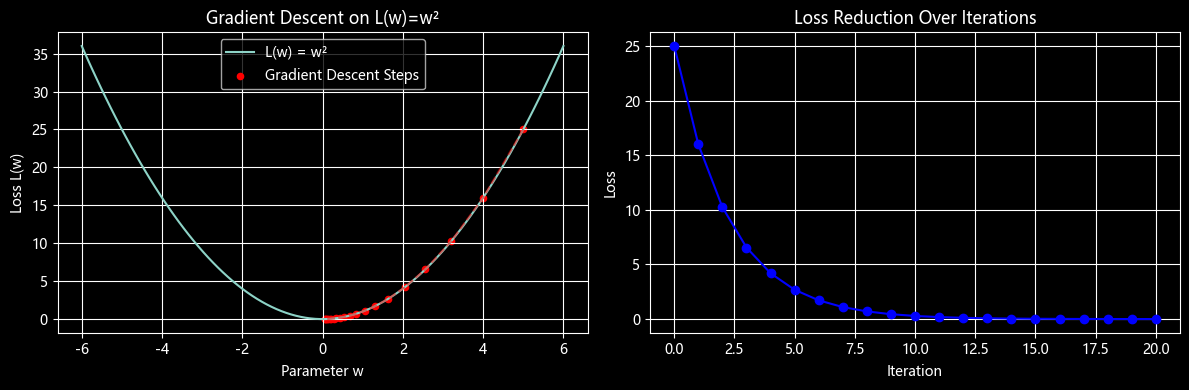

In [16]:
# 梯度

# 定义损失函数 L(w) = w^2
def loss(w):
    return w ** 2

# 定义梯度 dL/dw = 2*w
def gradient(w):
    return 2 * w

# 梯度下降算法
def gradient_descent(start_w, learning_rate, iterations):
    w = start_w
    w_history = [w]  # 记录 w 的变化历史
    loss_history = [loss(w)]  # 记录损失的变化历史

    for i in range(iterations):
        grad = gradient(w)  # 计算当前点的梯度
        w = w - learning_rate * grad  # 沿负梯度方向更新参数
        w_history.append(w)
        loss_history.append(loss(w))

    return w_history, loss_history

# 执行梯度下降：从 w=5 开始，学习率 0.1，迭代 20 次
w_start = 5.0
lr = 0.1
iters = 20
w_hist, loss_hist = gradient_descent(w_start, lr, iters)

print(f"初始 w: {w_hist[0]:.4f}, 初始损失: {loss_hist[0]:.4f}")
print(f"最终 w: {w_hist[-1]:.4f}, 最终损失: {loss_hist[-1]:.4f}")

# 可视化优化过程
plt.figure(figsize=(12, 4))

# 图1：损失函数曲线及优化路径
plt.subplot(1, 2, 1)
w_vals = np.linspace(-6, 6, 100)
plt.plot(w_vals, loss(w_vals), label='L(w) = w²')
plt.scatter(w_hist, loss_hist, c='red', s=20, label='Gradient Descent Steps')
plt.plot(w_hist, loss_hist, 'r--', alpha=0.5)
plt.xlabel('Parameter w')
plt.ylabel('Loss L(w)')
plt.title('Gradient Descent on L(w)=w²')
plt.legend()
plt.grid(True)

# 图2：损失值随迭代次数的下降曲线
plt.subplot(1, 2, 2)
plt.plot(range(len(loss_hist)), loss_hist, 'b-o')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Loss Reduction Over Iterations')
plt.grid(True)

plt.tight_layout()
plt.show()

过拟合、欠拟合

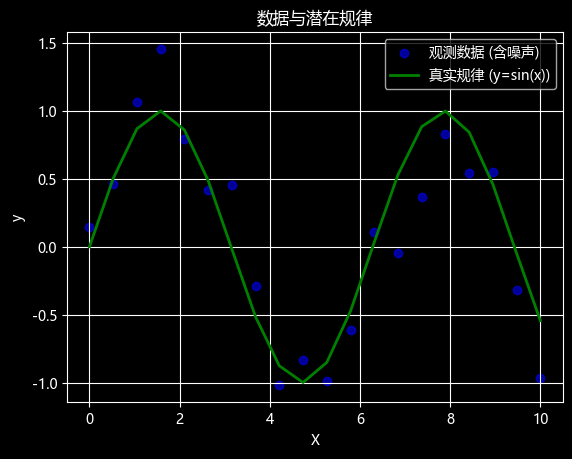

In [ ]:
# 拟合

# 生成模拟数据：在正弦曲线基础上加入一些随机噪声
np.random.seed(42)
X = np.linspace(0, 10, 20)
y_true = np.sin(X)                    # 真实的潜在规律（我们不知道）
y_noise = np.random.randn(20) * 0.3   # 随机噪声
y = y_true + y_noise                  # 我们实际观测到的数据

plt.scatter(X, y, label='观测数据 (含噪声)', color='blue', alpha=0.6)
plt.plot(X, y_true, label='真实规律 (y=sin(x))', color='green', linewidth=2)
plt.xlabel('X')
plt.ylabel('y')
plt.title('数据与潜在规律')
plt.legend()
plt.grid(True)
plt.show()

In [5]:
# 1. 欠拟合
"""
欠拟合:是指模型过于简单，无法捕捉数据中的基本规律或模式。
表现：模型在训练数据上表现就很差（例如，准确率低，误差大）。
原因：模型复杂度太低，特征不足，或训练不充分。
类比：用一条直线（一次多项式）去拟合有明显弯曲趋势的数据。
"""

# 若前面的单元未执行，兜底生成示例数据，避免 NameError
if 'X' not in globals() or 'y' not in globals():
	np.random.seed(42)
	X = np.linspace(0, 10, 20)
	y_true = np.sin(X)
	y_noise = np.random.randn(20) * 0.3
	y = y_true + y_noise

# 尝试用1阶多项式（直线）拟合
poly = PolynomialFeatures(degree=1)
X_poly1 = poly.fit_transform(X.reshape(-1, 1))
model_under = LinearRegression()
model_under.fit(X_poly1, y)
y_pred_under = model_under.predict(X_poly1)

mse_train_under = mean_squared_error(y, y_pred_under)
print(f"欠拟合模型在训练集上的均方误差 (MSE): {mse_train_under:.4f}")

欠拟合模型在训练集上的均方误差 (MSE): 0.4402


欠拟合模型在训练集上的均方误差 (MSE): 0.4402
良好拟合模型在训练集上的均方误差 (MSE): 0.3988
过拟合模型在训练集上的均方误差 (MSE): 0.0650


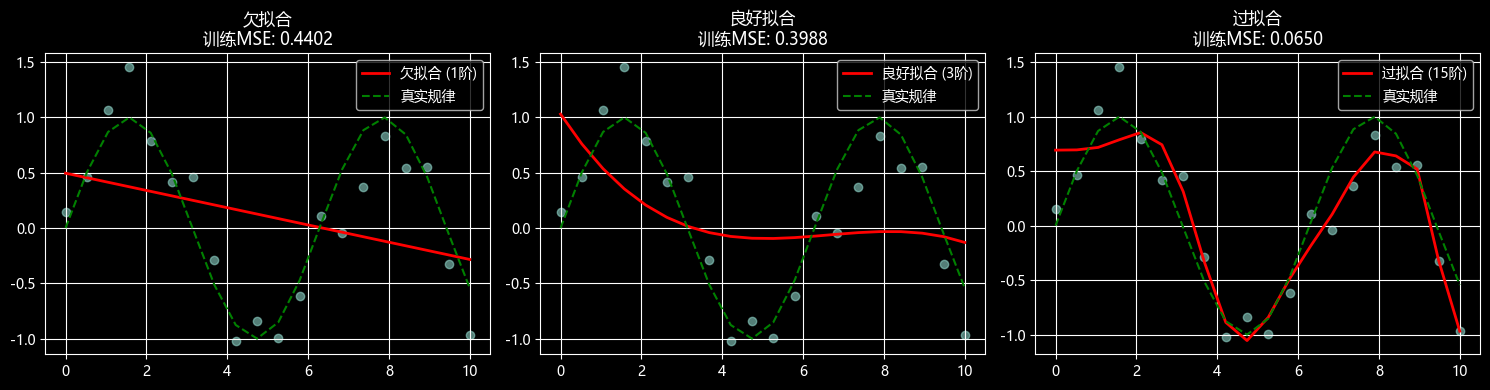

In [6]:
# 过拟合
"""
过拟合:是指模型过于复杂，不仅学习了数据中的真实规律，还"记住"了训练数据中的随机噪声和异常值。
表现：模型在训练数据上表现极好（误差极小），但在新的、未见过的数据上表现急剧下降，泛化能力差。
原因：模型复杂度过高，训练数据量太少。
类比：用一个非常高阶的多项式（例如15阶）去拟合数据，使得曲线穿过了几乎每一个数据点，变得极度扭曲。
"""

# 生成模拟数据：在正弦曲线基础上加入一些随机噪声
np.random.seed(42)
X = np.linspace(0, 10, 20)
y_true = np.sin(X)                     # 真实的潜在规律（我们不知道）
y_noise = np.random.randn(20) * 0.3   # 随机噪声
y = y_true + y_noise                  # 我们实际观测到的数据

# 尝试用1阶多项式（直线）拟合
poly = PolynomialFeatures(degree=1)
X_poly1 = poly.fit_transform(X.reshape(-1, 1))
model_under = LinearRegression()
model_under.fit(X_poly1, y)
y_pred_under = model_under.predict(X_poly1)

mse_train_under = mean_squared_error(y, y_pred_under)
print(f"欠拟合模型在训练集上的均方误差 (MSE): {mse_train_under:.4f}")

# 尝试用3阶多项式拟合
poly = PolynomialFeatures(degree=3)
X_poly3 = poly.fit_transform(X.reshape(-1, 1))
model_good = LinearRegression()
model_good.fit(X_poly3, y)
y_pred_good = model_good.predict(X_poly3)

mse_train_good = mean_squared_error(y, y_pred_good)
print(f"良好拟合模型在训练集上的均方误差 (MSE): {mse_train_good:.4f}")

# 尝试用15阶多项式拟合（极易过拟合）
poly = PolynomialFeatures(degree=15)
X_poly15 = poly.fit_transform(X.reshape(-1, 1))
model_over = LinearRegression()
model_over.fit(X_poly15, y)
y_pred_over = model_over.predict(X_poly15)

mse_train_over = mean_squared_error(y, y_pred_over)
print(f"过拟合模型在训练集上的均方误差 (MSE): {mse_train_over:.4f}")

# 可视化三种拟合状态
plt.figure(figsize=(15, 4))

# 欠拟合
plt.subplot(1, 3, 1)
plt.scatter(X, y, alpha=0.6)
plt.plot(X, y_pred_under, color='red', linewidth=2, label='欠拟合 (1阶)')
plt.plot(X, y_true, color='green', linestyle='--', label='真实规律')
plt.title(f'欠拟合\n训练MSE: {mse_train_under:.4f}')
plt.legend()
plt.grid(True)

# 良好拟合
plt.subplot(1, 3, 2)
plt.scatter(X, y, alpha=0.6)
plt.plot(X, y_pred_good, color='red', linewidth=2, label='良好拟合 (3阶)')
plt.plot(X, y_true, color='green', linestyle='--', label='真实规律')
plt.title(f'良好拟合\n训练MSE: {mse_train_good:.4f}')
plt.legend()
plt.grid(True)

# 过拟合
plt.subplot(1, 3, 3)
plt.scatter(X, y, alpha=0.6)
plt.plot(X, y_pred_over, color='red', linewidth=2, label='过拟合 (15阶)')
plt.plot(X, y_true, color='green', linestyle='--', label='真实规律')
plt.title(f'过拟合\n训练MSE: {mse_train_over:.4f}')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()
"""
欠拟合（左）：红色直线完全无法捕捉数据的波动趋势。
良好拟合（中）：红色曲线大致遵循了绿色真实规律的趋势。
过拟合（右）：红色曲线剧烈波动，试图穿过每一个蓝色散点，包括噪声点，完全失去了正弦曲线的光滑形态。
"""

偏差与方差  

偏差和方差为我们理解过拟合与欠拟合提供了理论框架。它们描述了模型误差的两个不同来源。  
我们可以将模型的总误差分解为：偏差² + 方差 + 不可减少的误差。  
1. 偏差  
定义：模型预测值的期望（即平均预测值）与真实值之间的差距。反映了模型本身的系统性错误，即模型对问题本质的假设是否有误。  
高偏差的表现：模型过于简单，无法刻画数据特征，导致欠拟合。无论用什么数据训练，结果都偏离真实值。  
例子：始终用"房价=面积×1000"这个简单线性模型来预测各种房子，忽略了地段、楼层等重要因素，这就是高偏差。  
2. 方差  
定义：模型预测值自身的波动范围。反映了模型对训练数据中随机噪声的敏感程度。  
高方差的表现：模型过于复杂，对训练数据中的微小变化（包括噪声）反应过度，导致过拟合。换一组数据训练，得到的模型可能完全不同。  
例子：一个深度神经网络，如果不对其进行任何约束，它可能会为每一套独特的训练数据生成一套完全不同的、极度复杂的预测规则，这就是高方差。  
3. 偏差-方差权衡  
这是一个机器学习中的核心权衡。我们无法同时最小化偏差和方差。  
增加模型复杂度：通常可以降低偏差（模型能力变强），但会增加方差（更容易学到噪声）。  
降低模型复杂度：通常可以降低方差（模型更稳定），但会增加偏差（模型能力变弱）。  
我们的目标就是找到图中的"最佳点"，使得总误差最小。  

欠拟合模型（1阶多项式 - 线性回归）


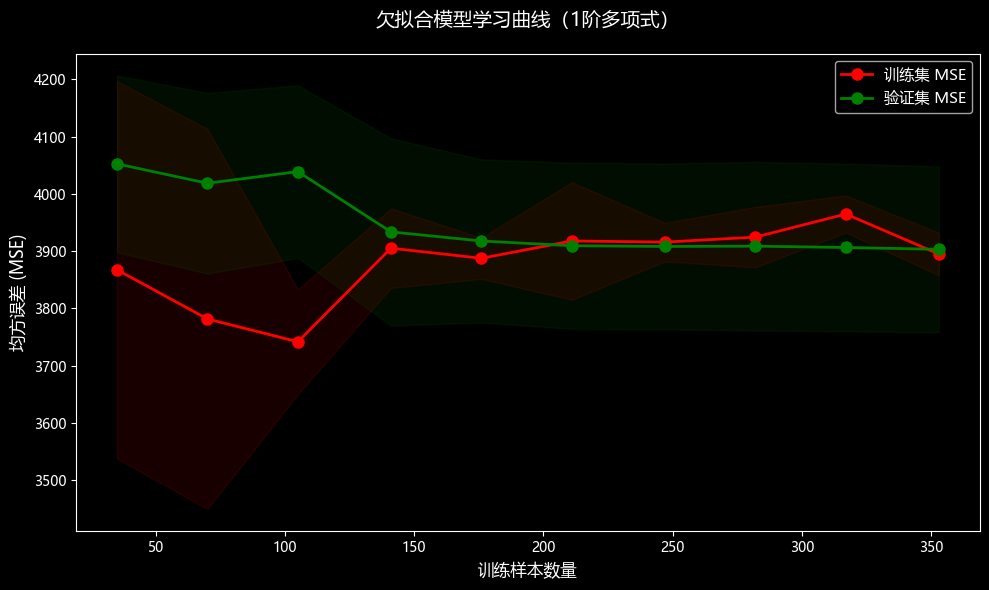

欠拟合模型学习曲线（1阶多项式） - 测试集 MSE: 4061.83

良好拟合模型（2阶多项式）


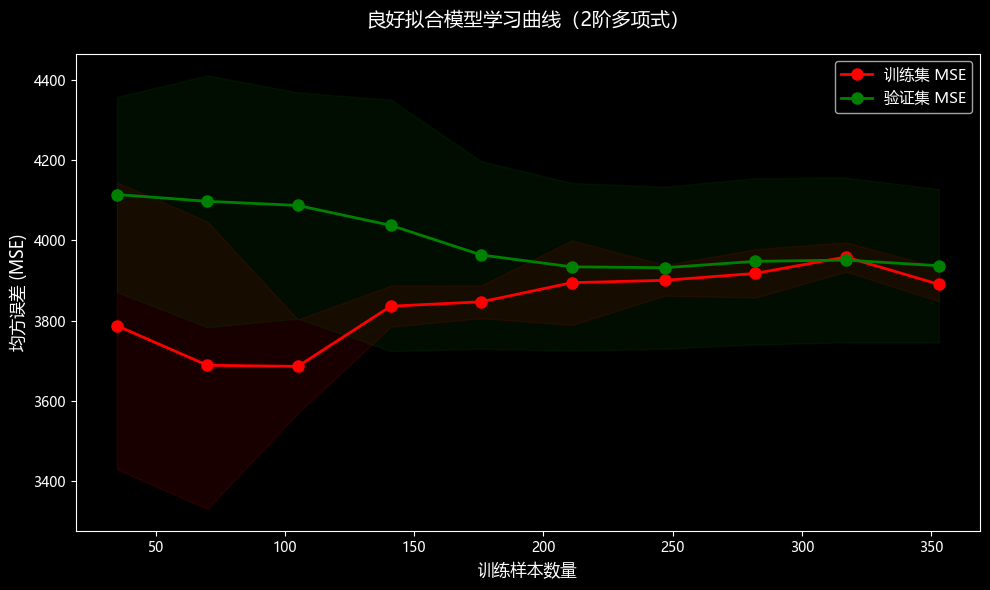

良好拟合模型学习曲线（2阶多项式） - 测试集 MSE: 4085.03

过拟合模型（8阶多项式）


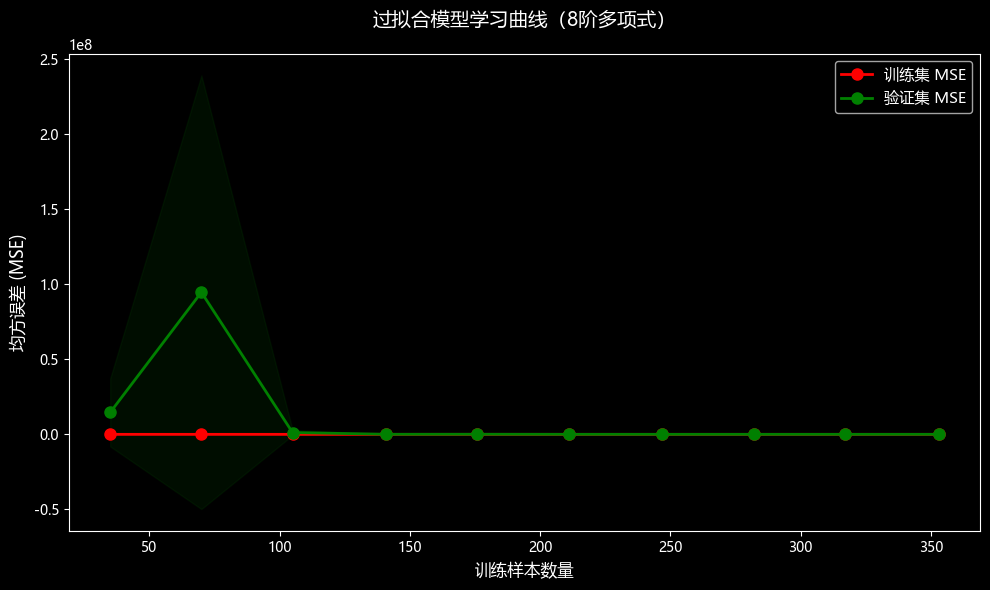

过拟合模型学习曲线（8阶多项式） - 测试集 MSE: 7875.32


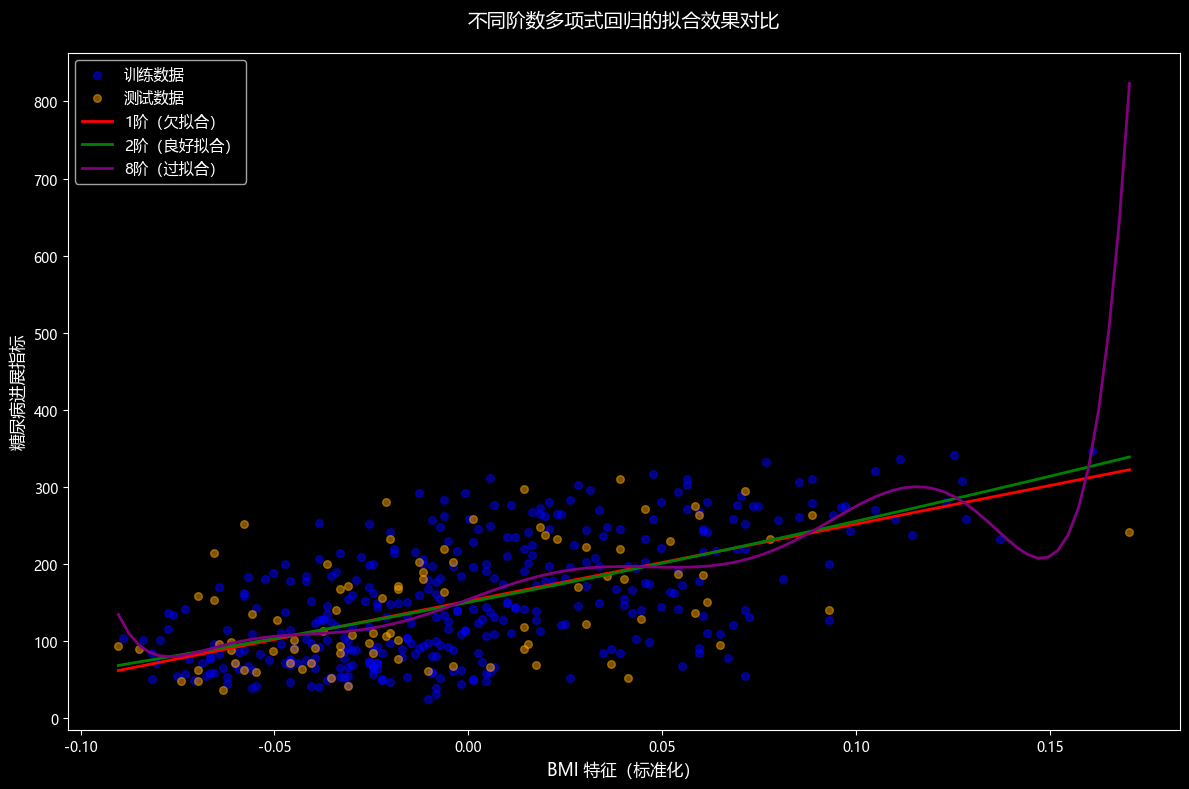

In [ ]:
warnings.filterwarnings('ignore')



# 加载数据 —— 糖尿病回归数据集
data = load_diabetes()
X, y = data.data, data.target
# 只使用一个特征（更适合多项式回归演示）
X = X[:, np.newaxis, 2]  # 选择第三个特征（BMI）
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 定义学习曲线绘制函数（优化版）
def plot_learning_curve(estimator, title, X, y, cv=5, train_sizes=np.linspace(0.1, 1.0, 10)):
    """
    绘制学习曲线
    参数：
        estimator: 模型估计器
        title: 图表标题
        X: 特征数据
        y: 目标变量
        cv: 交叉验证折数
        train_sizes: 训练样本比例
    """
    # 获取学习曲线数据
    train_sizes_abs, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, scoring='neg_mean_squared_error',
        train_sizes=train_sizes, random_state=42, n_jobs=-1
    )
    
    # 计算均值和标准差
    train_scores_mean = -train_scores.mean(axis=1)
    train_scores_std = train_scores.std(axis=1)
    test_scores_mean = -test_scores.mean(axis=1)
    test_scores_std = test_scores.std(axis=1)
    
    # 绘制学习曲线
    plt.figure(figsize=(10, 6))
    plt.fill_between(train_sizes_abs, 
                     train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, 
                     alpha=0.1, color='r')
    plt.fill_between(train_sizes_abs,
                     test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std,
                     alpha=0.1, color='g')
    
    # 绘制均值曲线
    plt.plot(train_sizes_abs, train_scores_mean, 'o-', color='r', linewidth=2,
             markersize=8, label='训练集 MSE')
    plt.plot(train_sizes_abs, test_scores_mean, 'o-', color='g', linewidth=2,
             markersize=8, label='验证集 MSE')
    
    # 设置图表属性
    plt.xlabel('训练样本数量', fontsize=12)
    plt.ylabel('均方误差 (MSE)', fontsize=12)
    plt.title(title, fontsize=14, pad=20)
    plt.legend(loc='upper right', fontsize=11)
    plt.tight_layout()
    plt.show()
    
    # 打印模型在测试集上的表现
    estimator.fit(X_train, y_train)
    y_pred = estimator.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    print(f"{title} - 测试集 MSE: {mse:.2f}")

# 1. 欠拟合模型（1阶多项式 - 线性回归）
print("="*60)
print("欠拟合模型（1阶多项式 - 线性回归）")
print("="*60)
plot_learning_curve(
    make_pipeline(StandardScaler(), PolynomialFeatures(1), LinearRegression()),
    '欠拟合模型学习曲线（1阶多项式）',
    X, y
)

# 2. 良好拟合模型（2阶多项式）
print("\n" + "="*60)
print("良好拟合模型（2阶多项式）")
print("="*60)
plot_learning_curve(
    make_pipeline(StandardScaler(), PolynomialFeatures(2), LinearRegression()),
    '良好拟合模型学习曲线（2阶多项式）',
    X, y
)

# 3. 过拟合模型（8阶多项式）
print("\n" + "="*60)
print("过拟合模型（8阶多项式）")
print("="*60)
plot_learning_curve(
    make_pipeline(StandardScaler(), PolynomialFeatures(8), LinearRegression()),
    '过拟合模型学习曲线（8阶多项式）',
    X, y
)

# 额外：可视化不同阶数模型的拟合效果
plt.figure(figsize=(12, 8))
X_plot = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)

# 绘制原始数据点
plt.scatter(X_train, y_train, alpha=0.5, label='训练数据', color='blue', s=30)
plt.scatter(X_test, y_test, alpha=0.5, label='测试数据', color='orange', s=30)

# 绘制不同阶数的拟合曲线
orders = [1, 2, 8]
colors = ['red', 'green', 'purple']
labels = ['1阶（欠拟合）', '2阶（良好拟合）', '8阶（过拟合）']

for i, order in enumerate(orders):
    model = make_pipeline(StandardScaler(), PolynomialFeatures(order), LinearRegression())
    model.fit(X_train, y_train)
    y_plot = model.predict(X_plot)
    plt.plot(X_plot, y_plot, color=colors[i], linewidth=2, label=labels[i])

plt.xlabel('BMI 特征（标准化）', fontsize=12)
plt.ylabel('糖尿病进展指标', fontsize=12)
plt.title('不同阶数多项式回归的拟合效果对比', fontsize=14, pad=20)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()
"""
拟合状态	训练误差	 验证误差	          曲线特征
欠拟合	       高	       高	   两条曲线都很高且非常接近，增加数据无帮助
良好拟合	   低	       低	   两条曲线都较低且彼此接近，达到一个平衡点
过拟合	     非常低	       高	   训练误差很低，但验证误差很高，中间有明显间隙。增加数据通常能使两者靠近
"""

"""
应对策略
根据诊断结果，我们可以采取不同策略：
1.解决欠拟合（高偏差）：
1)增加模型复杂度：使用更强大的模型（如从线性模型切换到树模型、神经网络）。
2)添加更多特征：挖掘或构造更有意义的特征。
3)减少正则化：如果使用了正则化（如 L1、L2），尝试减弱其强度。
4)延长训练时间：对于迭代模型（如神经网络），训练更多轮次。
2.解决过拟合（高方差）：
1)获取更多训练数据：最有效的方法之一。
2)降低模型复杂度：选择更简单的模型（如降低多项式阶数、减少树深度、减少神经网络层数）。
3)特征选择：移除不相关或冗余的特征。
4)增加正则化：
L1 正则化 (Lasso)：倾向于产生稀疏权重，可用于特征选择。
L2 正则化 (Ridge)：使权重衰减，倾向于让所有权重都较小。
Dropout（用于神经网络）：在训练中随机"丢弃"一部分神经元。
早停（用于迭代模型）：当验证集误差不再下降时停止训练。
"""

树最大深度: 1
  训练集 MSE: 4227.29
  测试集 MSE: 4606.59
------------------------------
树最大深度: 3
  训练集 MSE: 2935.04
  测试集 MSE: 3552.70
------------------------------
树最大深度: 10
  训练集 MSE: 375.60
  测试集 MSE: 4387.98
------------------------------
树最大深度: 无限制
  训练集 MSE: 0.00
  测试集 MSE: 4976.80
------------------------------


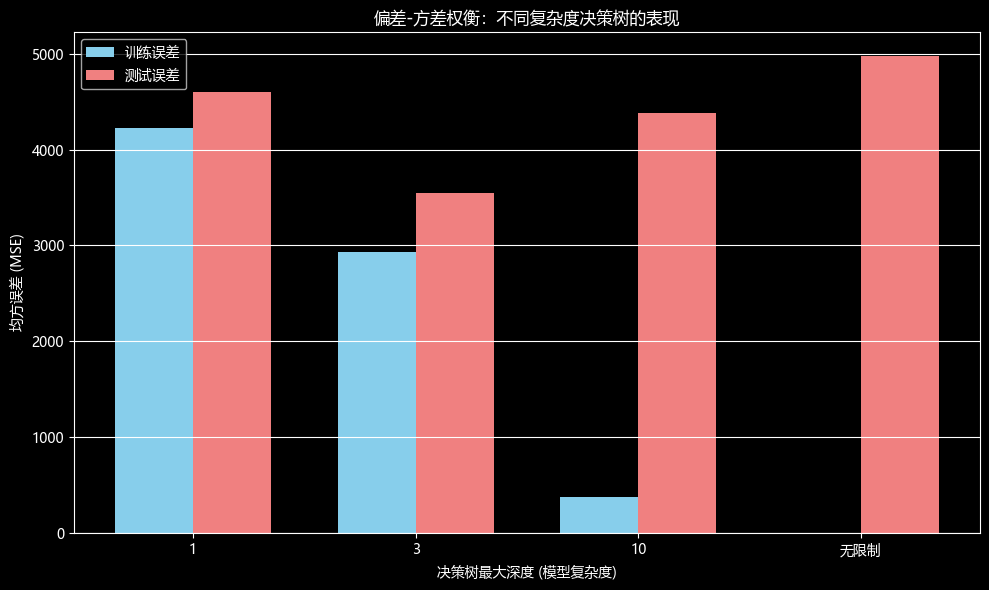

In [10]:
# 实践

# 加载数据
data = load_diabetes()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 尝试不同复杂度的决策树
max_depths = [1, 3, 10, None]  # None 表示不限制深度，树会一直生长直到"纯"
train_errors = []
test_errors = []

for depth in max_depths:
    model = DecisionTreeRegressor(max_depth=depth, random_state=42)
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_error = mean_squared_error(y_train, y_train_pred)
    test_error = mean_squared_error(y_test, y_test_pred)

    train_errors.append(train_error)
    test_errors.append(test_error)

    print(f"树最大深度: {depth if depth is not None else '无限制'}")
    print(f"  训练集 MSE: {train_error:.2f}")
    print(f"  测试集 MSE: {test_error:.2f}")
    print("-" * 30)

# 可视化
plt.figure(figsize=(10, 6))
depths = [str(d) if d else '无限制' for d in max_depths]
x_index = np.arange(len(depths))
width = 0.35

plt.bar(x_index - width/2, train_errors, width, label='训练误差', color='skyblue')
plt.bar(x_index + width/2, test_errors, width, label='测试误差', color='lightcoral')

plt.xlabel('决策树最大深度 (模型复杂度)')
plt.ylabel('均方误差 (MSE)')
plt.title('偏差-方差权衡：不同复杂度决策树的表现')
plt.xticks(x_index, depths)
plt.legend()
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()